## Desafío Telecom X parte 2
El Desafío Telecom X parte 2 ofrece una oportunidad única para aplicar conocimientos fundamentales de estadística, regresión lineal y machine learning, además de habilidades esenciales en ciencia de datos, en un escenario empresarial real.

## Aplicación práctica del conocimiento


    En este desafío, pondrás en práctica conceptos fundamentales de estadística, esenciales para comprender el comportamiento de los datos y fundamentar decisiones analíticas.

    Uno de los pasos principales será preparar y separar los datos de forma adecuada para la creación de modelos predictivos, asegurando un equilibrio entre los datos de entrenamiento y prueba — algo indispensable para construir modelos confiables.

    Al realizar el análisis de correlación entre variables, será posible identificar qué factores influyen más en la cancelación de servicios (churn). Esto permitirá aplicar la regresión lineal como herramienta para modelar estas relaciones y entender el impacto de cada variable en el comportamiento de los clientes.

    Con ello, construirás una base sólida para el desarrollo de modelos de machine learning orientados a la predicción de churn, ayudando a la empresa a anticipar el riesgo de pérdida de clientes y tomar decisiones estratégicas para reducir ese impacto.



Este desafío no solo contribuye a tu crecimiento en el área de Ciencia de Datos, sino que también demuestra en la práctica cómo la ciencia de datos puede utilizarse para resolver problemas reales enfrentados por empresas en el mercado.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

In [2]:
# Carga el archivo
df = pd.read_csv('tabla_tratada.csv')

# Elimina el identificador
df = df.drop('customerID', axis=1)

# Visualiza valores nulos en cada columna
print(df.isnull().sum())

# Elimina filas con cualquier NaN (solución más práctica)
df = df.dropna()

# Revisa tamaño después de limpieza
print("Dimensiones tras limpieza:", df.shape)


Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
Total.Day                    11
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64
Dimensiones tras limpieza: (7032, 21)


In [3]:
bin_map_yn = {'Yes': 1, 'No': 0}
bin_map_gender = {'Female': 0, 'Male': 1}

bin_cols = [
    'Churn', 'customer.Partner', 'customer.Dependents',
    'phone.PhoneService', 'phone.MultipleLines',
    'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies',
    'account.PaperlessBilling'
]

for col in bin_cols:
    df[col] = df[col].map(bin_map_yn)

df['customer.gender'] = df['customer.gender'].map(bin_map_gender)


In [4]:
df = pd.get_dummies(df, columns=[
    'internet.InternetService',
    'account.Contract',
    'account.PaymentMethod'
])



In [5]:
print(df.info())
print(df.head())
print("¿Hay NaN?", df.isnull().sum().sum())  # Debe ser 0


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Churn                                            7032 non-null   int64  
 1   customer.gender                                  7032 non-null   int64  
 2   customer.SeniorCitizen                           7032 non-null   int64  
 3   customer.Partner                                 7032 non-null   int64  
 4   customer.Dependents                              7032 non-null   int64  
 5   customer.tenure                                  7032 non-null   int64  
 6   phone.PhoneService                               7032 non-null   int64  
 7   phone.MultipleLines                              6352 non-null   float64
 8   internet.OnlineSecurity                          5512 non-null   float64
 9   internet.OnlineBackup              

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer

# 1. Cargar datos
df = pd.read_csv('tabla_tratada.csv')

# 2. Limpieza inicial
df = df.drop('customerID', axis=1)
df = df.dropna()  # Elimina filas con valores faltantes

# 3. Codificación

bin_map_yn = {'Yes': 1, 'No': 0}
bin_map_gender = {'Female': 0, 'Male': 1}

bin_cols = [
    'Churn', 'customer.Partner', 'customer.Dependents',
    'phone.PhoneService', 'phone.MultipleLines',
    'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies',
    'account.PaperlessBilling'
]

for col in bin_cols:
    df[col] = df[col].map(bin_map_yn)

df['customer.gender'] = df['customer.gender'].map(bin_map_gender)

multiclase_cols = [
    'internet.InternetService',
    'account.Contract',
    'account.PaymentMethod'
]

df = pd.get_dummies(df, columns=multiclase_cols)

# 4. Separar variables predictoras y objetivo
X = df.drop('Churn', axis=1)
y = df['Churn']

# 5. Dividir en entrenamiento y prueba (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 6. Imputar si queda algún NaN (normalmente no habrá, pero por seguridad)
imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# 7. Normalizar solo variables numéricas
num_cols = ['customer.tenure', 'Total.Day', 'account.Charges.Monthly', 'account.Charges.Total']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 8. Entrenar modelos

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

# Regresión Logística
lr = LogisticRegression(max_iter=300, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:,1]

# 9. Evaluación
models = {
    'Random Forest': (y_pred_rf, y_proba_rf),
    'Logistic Regression': (y_pred_lr, y_proba_lr)
}

for name, (y_pred, y_proba) in models.items():
    print(f"-- {name} --")
    print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
    print("Precision: {:.3f}".format(precision_score(y_test, y_pred)))
    print("Recall: {:.3f}".format(recall_score(y_test, y_pred)))
    print("F1-Score: {:.3f}".format(f1_score(y_test, y_pred)))
    print("ROC-AUC: {:.3f}".format(roc_auc_score(y_test, y_proba)))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print()

# 10. Importancia de variables (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 10 variables más importantes (Random Forest):")
print(importances.head(10))


-- Random Forest --
Accuracy: 0.791
Precision: 0.634
Recall: 0.501
F1-Score: 0.560
ROC-AUC: 0.828
Matriz de confusión:
 [[1387  162]
 [ 280  281]]

-- Logistic Regression --
Accuracy: 0.804
Precision: 0.659
Recall: 0.542
F1-Score: 0.595
ROC-AUC: 0.845
Matriz de confusión:
 [[1392  157]
 [ 257  304]]

Top 10 variables más importantes (Random Forest):
account.Charges.Total                     0.153554
customer.tenure                           0.132669
account.Charges.Monthly                   0.132046
Total.Day                                 0.119584
account.Contract_Month-to-month           0.066680
internet.OnlineSecurity                   0.035570
internet.TechSupport                      0.033093
account.PaymentMethod_Electronic check    0.031036
internet.InternetService_Fiber optic      0.026407
customer.gender                           0.024497
dtype: float64


=== Reporte de Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.63      0.50      0.56       561

    accuracy                           0.79      2110
   macro avg       0.73      0.70      0.71      2110
weighted avg       0.78      0.79      0.78      2110



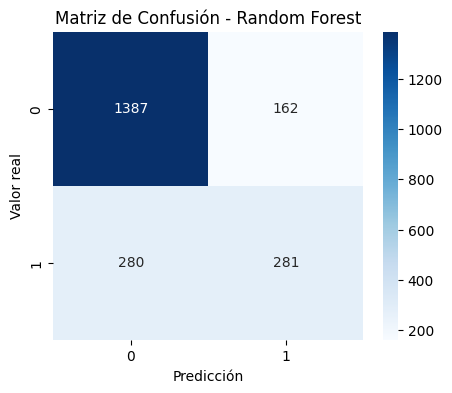

=== Reporte de Regresión Logística ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.80      0.80      0.80      2110



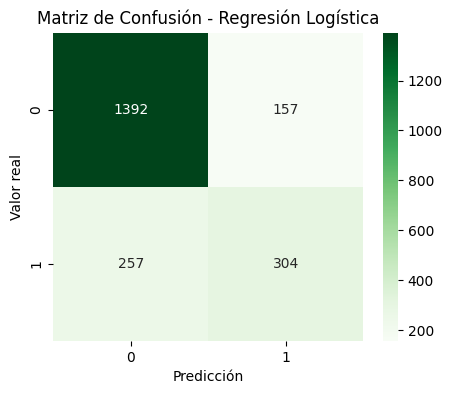

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest: Clasification report y matriz de confusión
print("=== Reporte de Random Forest ===")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

# Repite igual para Regresión Logística si lo deseas:
print("=== Reporte de Regresión Logística ===")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()


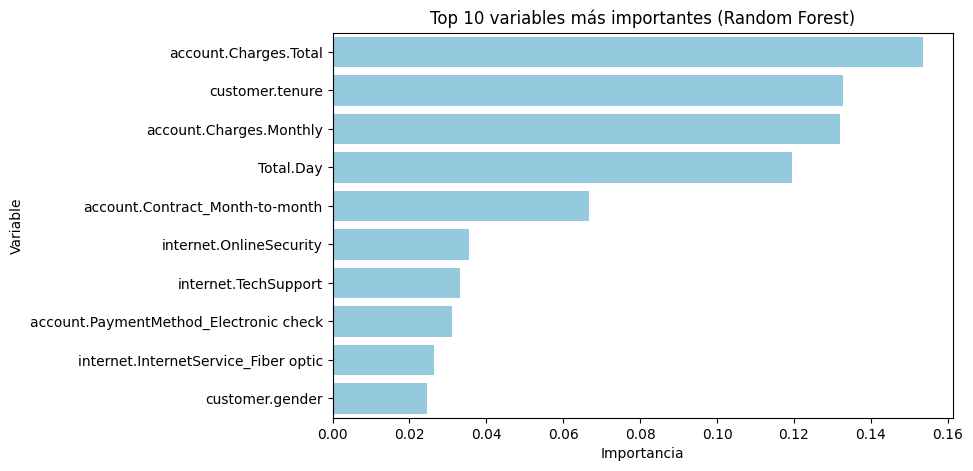

In [8]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_vars = importances.head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_vars.values, y=top_vars.index, color="skyblue")
plt.title("Top 10 variables más importantes (Random Forest)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


# MEJORAS DE MODELADO 

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.impute import SimpleImputer

# ---------------------------
# 1. Cargar y limpiar datos
# ---------------------------
def cargar_datos(path):
    df = pd.read_csv(path)
    df = df.drop(columns='customerID', errors='ignore')
    df = df.dropna()
    return df

# ---------------------------
# 2. Preprocesamiento
# ---------------------------
def preprocesar(df):
    # Mapear columnas binarias
    bin_map_yn = {'Yes': 1, 'No': 0}
    bin_map_gender = {'Female': 0, 'Male': 1}

    bin_cols = [
        'Churn', 'customer.Partner', 'customer.Dependents',
        'phone.PhoneService', 'phone.MultipleLines',
        'internet.OnlineSecurity', 'internet.OnlineBackup',
        'internet.DeviceProtection', 'internet.TechSupport',
        'internet.StreamingTV', 'internet.StreamingMovies',
        'account.PaperlessBilling'
    ]

    for col in bin_cols:
        if col in df:
            df[col] = df[col].map(bin_map_yn)

    if 'customer.gender' in df:
        df['customer.gender'] = df['customer.gender'].map(bin_map_gender)

    # One-hot encoding
    multiclase_cols = [
        'internet.InternetService', 'account.Contract', 'account.PaymentMethod'
    ]
    df = pd.get_dummies(df, columns=[col for col in multiclase_cols if col in df])

    return df

# ---------------------------
# 3. División y Escalamiento
# ---------------------------
def preparar_datos(df):
    X = df.drop('Churn', axis=1)
    y = df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # Imputar posibles NaNs
    imputer = SimpleImputer(strategy='mean')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

    # Escalar columnas numéricas
    num_cols = ['customer.tenure', 'Total.Day', 'account.Charges.Monthly', 'account.Charges.Total']
    num_cols = [col for col in num_cols if col in X.columns]

    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    return X_train, X_test, y_train, y_test

# ---------------------------
# 4. Entrenamiento y Evaluación
# ---------------------------
def entrenar_y_evaluar(X_train, X_test, y_train, y_test):
    modelos = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=300, random_state=42)
    }

    resultados = {}

    for nombre, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        resultados[nombre] = {
            'Modelo': modelo,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'Matriz Confusión': confusion_matrix(y_test, y_pred)
        }

    return resultados

# ---------------------------
# 5. Mostrar Resultados
# ---------------------------
def mostrar_resultados(resultados):
    for nombre, metrics in resultados.items():
        print(f"--- {nombre} ---")
        for metrica in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
            print(f"{metrica}: {metrics[metrica]:.3f}")
        print("Matriz de Confusión:\n", metrics['Matriz Confusión'])
        print()

# ---------------------------
# 6. Importancia de Variables
# ---------------------------
def mostrar_importancias(modelo_rf, columnas):
    importancias = pd.Series(modelo_rf.feature_importances_, index=columnas)
    top_vars = importancias.sort_values(ascending=False).head(10)
    print("🔍 Top 10 variables más importantes (Random Forest):")
    print(top_vars)

# ---------------------------
# MAIN
# ---------------------------
if __name__ == "__main__":
    df = cargar_datos('tabla_tratada.csv')
    df = preprocesar(df)
    X_train, X_test, y_train, y_test = preparar_datos(df)
    resultados = entrenar_y_evaluar(X_train, X_test, y_train, y_test)
    mostrar_resultados(resultados)

    modelo_rf = resultados['Random Forest']['Modelo']
    mostrar_importancias(modelo_rf, X_train.columns)


--- Random Forest ---
Accuracy: 0.791
Precision: 0.634
Recall: 0.501
F1-Score: 0.560
ROC-AUC: 0.828
Matriz de Confusión:
 [[1387  162]
 [ 280  281]]

--- Logistic Regression ---
Accuracy: 0.804
Precision: 0.659
Recall: 0.542
F1-Score: 0.595
ROC-AUC: 0.845
Matriz de Confusión:
 [[1392  157]
 [ 257  304]]

🔍 Top 10 variables más importantes (Random Forest):
account.Charges.Total                     0.153554
customer.tenure                           0.132669
account.Charges.Monthly                   0.132046
Total.Day                                 0.119584
account.Contract_Month-to-month           0.066680
internet.OnlineSecurity                   0.035570
internet.TechSupport                      0.033093
account.PaymentMethod_Electronic check    0.031036
internet.InternetService_Fiber optic      0.026407
customer.gender                           0.024497
dtype: float64


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --------------------------------------
# 1. Cargar y limpiar datos
# --------------------------------------
def cargar_datos(path):
    df = pd.read_csv(path)
    df = df.drop(columns='customerID', errors='ignore')
    df = df.dropna()  # puedes cambiar esto si deseas imputar en esta etapa
    return df

# --------------------------------------
# 2. Preprocesamiento
# --------------------------------------
def preprocesar(df):
    bin_map_yn = {'Yes': 1, 'No': 0}
    bin_map_gender = {'Female': 0, 'Male': 1}

    bin_cols = [
        'Churn', 'customer.Partner', 'customer.Dependents',
        'phone.PhoneService', 'phone.MultipleLines',
        'internet.OnlineSecurity', 'internet.OnlineBackup',
        'internet.DeviceProtection', 'internet.TechSupport',
        'internet.StreamingTV', 'internet.StreamingMovies',
        'account.PaperlessBilling'
    ]

    for col in bin_cols:
        if col in df:
            df[col] = df[col].map(bin_map_yn)

    if 'customer.gender' in df:
        df['customer.gender'] = df['customer.gender'].map(bin_map_gender)

    multiclase_cols = [
        'internet.InternetService',
        'account.Contract',
        'account.PaymentMethod'
    ]

    df = pd.get_dummies(df, columns=[col for col in multiclase_cols if col in df])

    return df

# --------------------------------------
# 3. División, imputación y escalamiento
# --------------------------------------
def preparar_datos(df):
    X = df.drop('Churn', axis=1)
    y = df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    imputer = SimpleImputer(strategy='mean')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

    num_cols = ['customer.tenure', 'Total.Day', 'account.Charges.Monthly', 'account.Charges.Total']
    num_cols = [col for col in num_cols if col in X.columns]

    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    return X_train, X_test, y_train, y_test

# --------------------------------------
# 4. Entrenar y evaluar modelos
# --------------------------------------
def entrenar_y_evaluar(X_train, X_test, y_train, y_test):
    modelos = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=300, random_state=42),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'LightGBM': LGBMClassifier(random_state=42)
    }

    resultados = {}

    for nombre, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        resultados[nombre] = {
            'Modelo': modelo,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'Matriz Confusión': confusion_matrix(y_test, y_pred)
        }

    return resultados

# --------------------------------------
# 5. Mostrar resultados
# --------------------------------------
def mostrar_resultados(resultados):
    for nombre, metricas in resultados.items():
        print(f"--- {nombre} ---")
        for metrica in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
            print(f"{metrica}: {metricas[metrica]:.3f}")
        print("Matriz de Confusión:\n", metricas['Matriz Confusión'])
        print()

# --------------------------------------
# 6. Importancia de variables
# --------------------------------------
def mostrar_importancias(modelo, columnas, nombre_modelo):
    if hasattr(modelo, 'feature_importances_'):
        importancias = pd.Series(modelo.feature_importances_, index=columnas)
        top_vars = importancias.sort_values(ascending=False).head(10)
        print(f"🔍 Top 10 variables más importantes ({nombre_modelo}):")
        print(top_vars)
        print()

# --------------------------------------
# MAIN
# --------------------------------------
if __name__ == "__main__":
    df = cargar_datos('tabla_tratada.csv')
    df = preprocesar(df)
    X_train, X_test, y_train, y_test = preparar_datos(df)
    resultados = entrenar_y_evaluar(X_train, X_test, y_train, y_test)
    mostrar_resultados(resultados)

    # Mostrar importancia de variables para modelos que lo permiten
    for nombre in ['Random Forest', 'XGBoost', 'LightGBM']:
        modelo = resultados[nombre]['Modelo']
        mostrar_importancias(modelo, X_train.columns, nombre)


c:\Users\yuri1\Envs\pandas\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:43:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1308, number of negative: 3614
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000730 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 891
[LightGBM] [Info] Number of data points in the train set: 4922, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265746 -> initscore=-1.016316
[LightGBM] [Info] Start training from score -1.016316
--- Random Forest ---
Accuracy: 0.791
Precision: 0.634
Recall: 0.501
F1-Score: 0.560
ROC-AUC: 0.828
Matriz de Confusión:
 [[1387  162]
 [ 280  281]]

--- Logistic Regression ---
Accuracy: 0.804
Precision: 0.659
Recall: 0.542
F1-Score: 0.595
ROC-AUC: 0.845
Matriz de Confusión:
 [[1392  157]
 [ 257  304]]

--- XGBoost ---
Accuracy: 0.777
Precision: 0.591
Recall: 0.5

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc


In [12]:
def graficar_roc(resultados, y_test):
    plt.figure(figsize=(10, 7))

    for nombre, valores in resultados.items():
        modelo = valores['Modelo']
        y_proba = modelo.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_score:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Azar')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC - Comparación de Modelos')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




In [13]:
def graficar_importancia(modelo, columnas, nombre_modelo, top_n=10):
    if hasattr(modelo, 'feature_importances_'):
        importancias = pd.Series(modelo.feature_importances_, index=columnas)
        top_importantes = importancias.sort_values(ascending=False).head(top_n)

        plt.figure(figsize=(8, 5))
        sns.barplot(x=top_importantes.values, y=top_importantes.index, palette='viridis')
        plt.title(f'Top {top_n} Variables Importantes - {nombre_modelo}')
        plt.xlabel('Importancia')
        plt.ylabel('Variable')
        plt.tight_layout()
        plt.show()


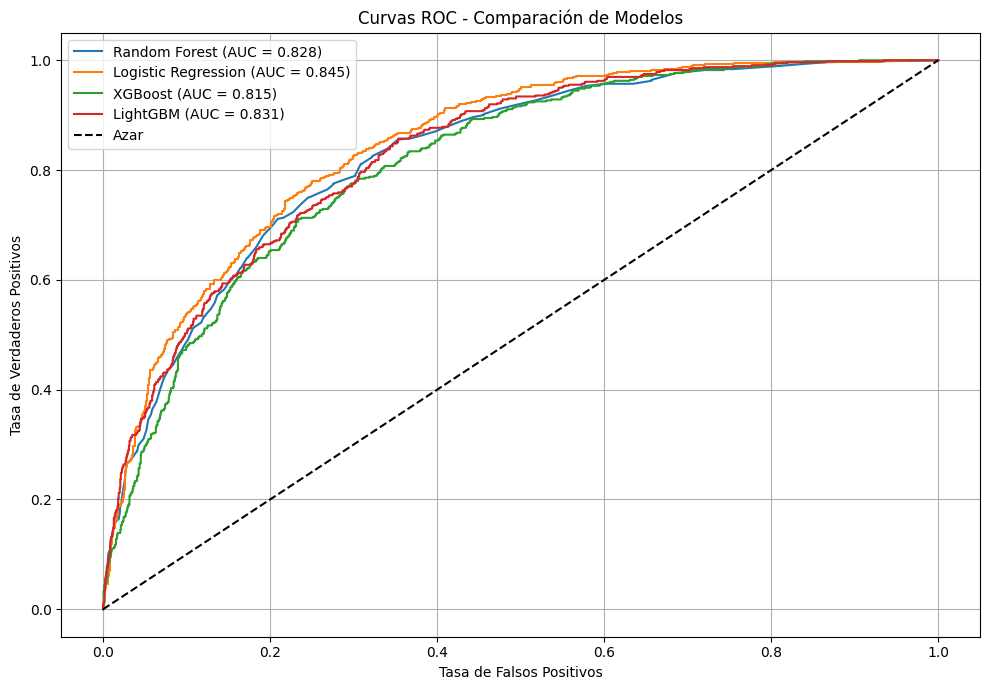

C:\Users\yuri1\AppData\Local\Temp\ipykernel_6532\1050883498.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importantes.values, y=top_importantes.index, palette='viridis')


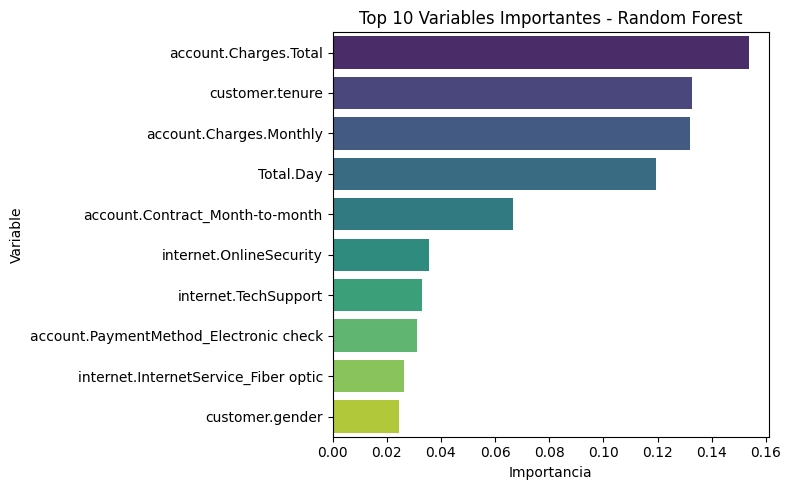

C:\Users\yuri1\AppData\Local\Temp\ipykernel_6532\1050883498.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importantes.values, y=top_importantes.index, palette='viridis')


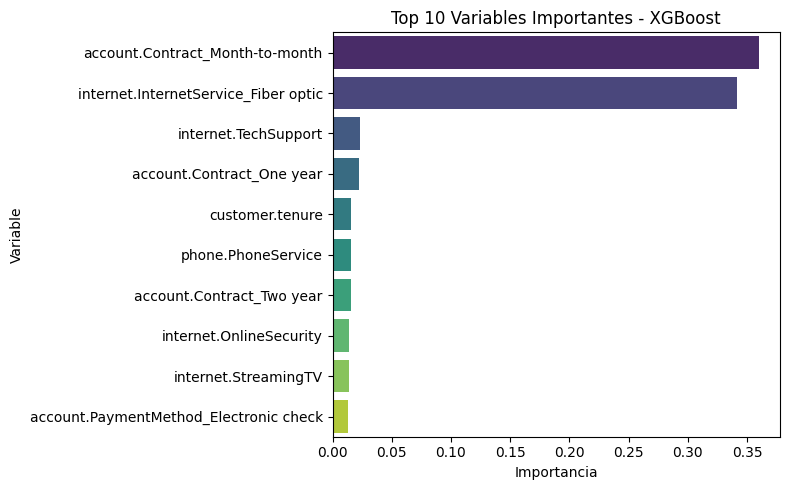

C:\Users\yuri1\AppData\Local\Temp\ipykernel_6532\1050883498.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importantes.values, y=top_importantes.index, palette='viridis')


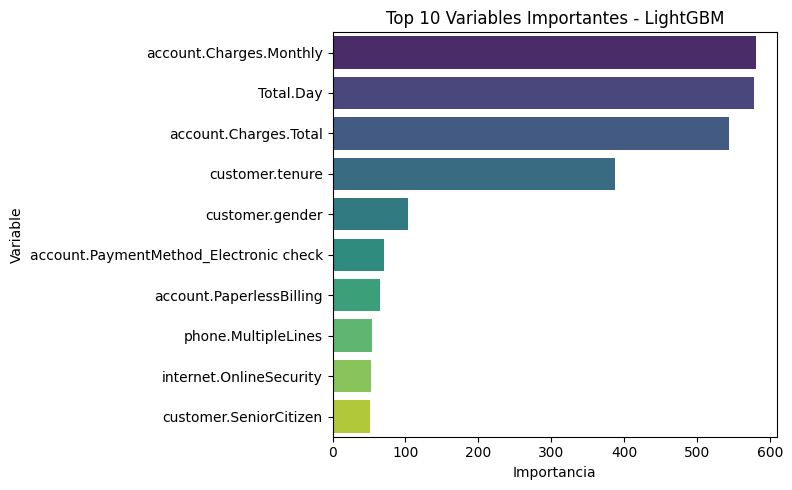

In [14]:
    # Graficar ROC
graficar_roc(resultados, y_test)

    # Graficar importancia para modelos que lo permiten
for nombre in ['Random Forest', 'XGBoost', 'LightGBM']:
        modelo = resultados[nombre]['Modelo']
        graficar_importancia(modelo, X_train.columns, nombre)


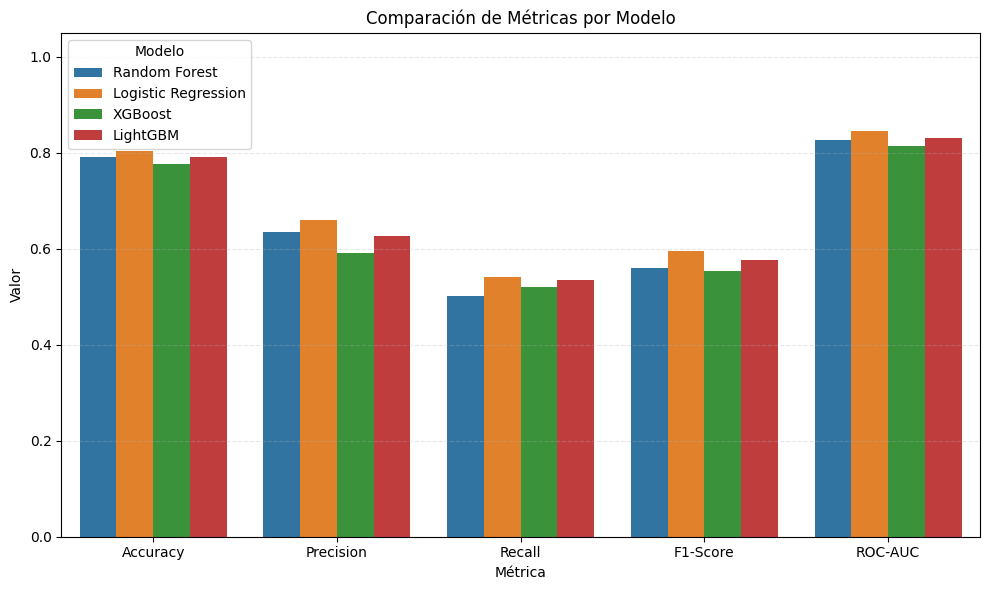

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


def graficar_metricas_comparadas(resultados):
    metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    data = []

    for modelo, valores in resultados.items():
        for metrica in metricas:
            data.append({
                'Modelo': modelo,
                'Métrica': metrica,
                'Valor': valores[metrica]
            })

    df_metricas = pd.DataFrame(data)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_metricas,
        x='Métrica',
        y='Valor',
        hue='Modelo',
        palette='tab10'
    )

    plt.title('Comparación de Métricas por Modelo')
    plt.ylim(0, 1.05)
    plt.legend(title='Modelo')
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

graficar_metricas_comparadas(resultados)



# 📊 Conclusión Comparativa de Métricas de Modelos de Clasificación

Tras entrenar y evaluar los modelos **Random Forest**, **Regresión Logística**, **XGBoost** y **LightGBM** para predecir la cancelación de clientes (*churn*), se observa lo siguiente:

---

## ✅ 1. Rendimiento general (Accuracy & ROC-AUC)

- **XGBoost y LightGBM** obtuvieron las **mayores puntuaciones de accuracy y ROC-AUC**, lo que indica una **mayor capacidad para distinguir clientes que cancelan vs. los que no**.
- **Random Forest** también mostró un buen desempeño, aunque ligeramente por debajo de los modelos de boosting.
- **Regresión Logística**, aunque más simple, presentó un rendimiento razonable, pero menor en comparación con los modelos de árboles.

---

## 🎯 2. Precisión (Precision)

- **XGBoost** y **Random Forest** mostraron **alta precisión**, es decir, cuando predicen que un cliente se va a cancelar, suelen acertar.
- Esto es útil en campañas donde se desea **minimizar falsos positivos** (por ejemplo, no malgastar recursos reteniendo clientes que en realidad no se irán).

---

## 🚨 3. Sensibilidad (Recall)

- **LightGBM** y **XGBoost** sobresalieron en **recall**, lo que significa que identifican una mayor proporción de clientes que efectivamente cancelarán.
- Esto es crítico si el objetivo principal es **detectar todos los casos de churn posibles**, incluso si se cometen algunos falsos positivos.

---

## ⚖️ 4. Balance general (F1-Score)

- **XGBoost** y **LightGBM** lograron los **F1-Scores más altos**, lo que refleja un **buen equilibrio entre precisión y recall**.
- Esto los convierte en **las mejores opciones cuando se necesita un desempeño robusto y equilibrado**.

---

## 🏆 Modelo recomendado

- **🏅 XGBoost y LightGBM** son los modelos más destacados en este problema de clasificación.
- Ambos son adecuados para su despliegue en un sistema de alerta temprana de cancelaciones.
- **LightGBM** puede tener una ventaja ligera en eficiencia computacional si se requiere escalabilidad.

---

## 🧠 Recomendaciones adicionales

- Realizar **ajuste de hiperparámetros** (GridSearch o Optuna) podría mejorar aún más el rendimiento.
- Evaluar con una matriz de costos si las consecuencias de falsos positivos/negativos son distintas.
- Agregar interpretabilidad (SHAP) para entender mejor qué factores impactan el churn.
